# Delivery Lead-Time Exploratory Data Analysis

**IT5006 · Milestone 1 · 2026-09-06**

Research question: what characterises purchase-to-delivery duration, and which order attributes warrant investigation in a later regression task? This module contains descriptive exploratory analysis; no predictive model is trained.

All data preparation, computation and plotting functions are included below. This notebook can run independently with the course Olist ZIP and the listed Python packages; no project-specific Python module is required.

## tl;dr

- The primary cohort contains **96,470** delivered orders with item records and valid, non-negative elapsed time.
- Median lead time is **10.22 days** (mean **12.56**; P90 **23.10**).
- Median lead time is **6.55 days** for all-sellers-same-state orders and **12.78 days** when any seller is cross-state. These are descriptive comparisons, not causal effects.
- Total freight has an unadjusted Spearman correlation of **0.382** with duration; associations weaken within route groups. Geography, purchase timing and freight merit later investigation; these plots do not establish out-of-sample prediction quality.
- Six records have `status=canceled` despite an actual delivery timestamp and are excluded from the primary cohort. Eight delivered orders lack the timestamps required to calculate the target.

This summary describes the supplied archive with SHA-256 `90ee50730a9e799aa2d3c7b1758fef680cbbc366f61a287870144796a37156d4`. The setup below checks that fingerprint before using these fixed summary claims.

## Context & Methods

**Stakeholder:** fulfilment planning and customer-service teams seeking realistic delivery-time estimates. **Target:** elapsed days from purchase to actual customer delivery, using `(actual - purchase).total_seconds()/86400`. It is not days late relative to a promised date.

### Key Assumptions

- One row represents one order; item attributes are aggregated before the order-level join.
- Primary eligibility: an item record, `order_status == delivered`, both target timestamps present, and non-negative elapsed time. This characterises eventual completed deliveries, not cancelled or still-undelivered orders.
- Source timestamps are timezone-naive. We use their supplied clock differences without assigning a timezone or making a timezone conversion.
- No upper-duration cutoff is imposed. A 60-day restriction is a labelled sensitivity check only.
- Seller/customer locations, item counts, price, freight and product attributes are assumed available when an order is placed; the archive does not prove historical feature-availability timing. Verify this assumption for Phase 2.
- Actual delivery timestamps and later events are used to calculate/audit outcomes, never as proposed predictors. The derived table is an analysis table, not a ready-to-fit feature matrix.
- M1 uses the historical dataset for descriptive discovery. In M2, reserve test data before further data-driven feature/model selection; fit preprocessing only on training folds and consider temporal validation and repeated customers.

The course asks for candidate exploration in M1; it does not require a fitted regression model at this stage.

### Data preparation rules

The order-level table is reconstructed from the teacher's CSV archive. Item attributes are aggregated before joining to orders. Eligibility requires delivered status and valid purchase/delivery timestamps; duration retains fractional days. Seller and category composition are represented without selecting an arbitrary first seller or category.

The source archive remains compressed and unchanged. Six relevant tables are used; payments, reviews and geolocation are not joined because their additional one-to-many relationships are unnecessary for the present questions. The cohort rules, data-quality checks and sensitivity analysis are documented and executed in the following sections.

### 1. Setup and source configuration

Use the **course-provided `IT5006_Project-Data.zip`**, with CSV files inside `Olist_CSV/`; the fingerprint check guards the fixed summary above. Keep this ZIP in the repository's `data/` directory or beside the notebook, or set `DATA_ZIP` in the next cell to its location. In Colab, upload the ZIP or mount Drive first and use that path.

Verified environment: Python 3.12; pandas 2.2.3, NumPy 2.3.5, SciPy 1.18.1, Matplotlib 3.11.1, IPython 9.17.1. Install missing packages in the active notebook environment before running all cells. The statistical methods and plots are deterministic; other package versions have not been verified.

Derived tables, audit data and figures are written to `delivery_lead_time_outputs/` in the working directory. `OLIST_DATA_ZIP` and `DELIVERY_EDA_OUTPUT_DIR` are optional environment overrides. The raw archive is read only.


In [1]:
from pathlib import Path
import os
import hashlib
import importlib.metadata
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Image

# Set this to Path("path/to/IT5006_Project-Data.zip") if the ZIP is elsewhere.
DATA_ZIP = None
if DATA_ZIP is None:
    if os.environ.get("OLIST_DATA_ZIP"):
        DATA_ZIP = Path(os.environ["OLIST_DATA_ZIP"])
    else:
        candidates = [Path("data/IT5006_Project-Data.zip"),
                      Path("../data/IT5006_Project-Data.zip"),
                      Path("IT5006_Project-Data.zip")]
        DATA_ZIP = next((p for p in candidates if p.is_file()), candidates[0])
DATA_ZIP = Path(DATA_ZIP).expanduser()
if not DATA_ZIP.is_file():
    raise FileNotFoundError("Course ZIP not found. Set DATA_ZIP to its location, or put it in data/ or beside this notebook.")
EXPECTED_SHA256 = "90ee50730a9e799aa2d3c7b1758fef680cbbc366f61a287870144796a37156d4"
assert hashlib.sha256(DATA_ZIP.read_bytes()).hexdigest() == EXPECTED_SHA256, "Source changed: review methods and summary before rerunning."
OUTPUT_DIR = Path(os.environ.get("DELIVERY_EDA_OUTPUT_DIR", "delivery_lead_time_outputs")).expanduser()
for folder in ["tables", "data", "figures"]:
    (OUTPUT_DIR / folder).mkdir(parents=True, exist_ok=True)
DEFAULT_ZIP, BASE = DATA_ZIP, OUTPUT_DIR
BLUE, GOLD, INK, GREY = '#3268A8', '#C49A32', '#263445', '#D9DFE6'
NUMERIC_FEATURES = ['total_freight', 'total_price', 'freight_ratio',
                    'avg_product_weight_g', 'item_count', 'seller_count']
pd.options.display.float_format = "{:,.3f}".format
print("Source ZIP fingerprint verified; output directories ready.")


Source ZIP fingerprint verified; output directories ready.


#### Source loading and order preparation

These functions validate table keys and aggregate items before constructing the order-level sample.

In [2]:
def load_tables(zip_path=DEFAULT_ZIP):
    """Read only the six needed CSV tables directly from the teacher archive."""
    tables, provenance = {}, []
    with zipfile.ZipFile(zip_path) as archive:
        for name in ['orders', 'order_items', 'customers', 'sellers', 'products', 'translation']:
            filename = ('product_category_name_translation.csv' if name == 'translation'
                        else f'olist_{name}_dataset.csv')
            member = f'Olist_CSV/{filename}'
            raw = archive.read(member)
            import io
            frame = pd.read_csv(io.BytesIO(raw))
            tables[name] = frame
            provenance.append({'table': name, 'zip_member': member, 'rows': len(frame),
                               'columns': len(frame.columns),
                               'sha256': hashlib.sha256(raw).hexdigest()})
    return tables, pd.DataFrame(provenance)


def prepare_orders(tables):
    """Validate keys; aggregate items before left-joining to one row per order."""
    orders, customers, sellers, products, items, translation = [
        tables[k].copy() for k in ['orders', 'customers', 'sellers', 'products', 'order_items', 'translation']]
    for frame, key in [(orders, 'order_id'), (customers, 'customer_id'),
                       (sellers, 'seller_id'), (products, 'product_id'),
                       (translation, 'product_category_name')]:
        assert frame[key].notna().all() and frame[key].is_unique, f'Invalid key: {key}'
    assert not items.duplicated(['order_id', 'order_item_id']).any()
    assert items[['order_id', 'order_item_id']].notna().all().all()
    fk_checks = [
        ('orders_to_customers', orders.customer_id, customers.customer_id),
        ('items_to_orders', items.order_id, orders.order_id),
        ('items_to_products', items.product_id, products.product_id),
        ('items_to_sellers', items.seller_id, sellers.seller_id)]
    integrity = pd.DataFrame([{'relationship': name, 'unmatched_rows': int((~left.isin(right)).sum())}
                              for name, left, right in fk_checks])
    assert integrity.unmatched_rows.eq(0).all(), 'Review unexpected orphan keys'
    for column in [c for c in orders if c.startswith('order_') and ('date' in c or 'timestamp' in c or c == 'order_approved_at')]:
        orders[column] = pd.to_datetime(orders[column], errors='raise')
    products = products.merge(translation, on='product_category_name', how='left', validate='many_to_one')
    # An untranslated Portuguese label is preserved; it is not silently dropped.
    products['category_label'] = products.product_category_name_english.fillna(products.product_category_name)
    products['weight_g_valid'] = products.product_weight_g.where(products.product_weight_g > 0)
    enriched = (items.merge(products[['product_id', 'category_label', 'weight_g_valid']],
                            on='product_id', how='left', validate='many_to_one')
               .merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left', validate='many_to_one')
               .merge(orders[['order_id', 'customer_id']], on='order_id', how='left', validate='many_to_one')
               .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left', validate='many_to_one'))
    assert len(enriched) == len(items)
    enriched['route_known'] = enriched.seller_state.notna() & enriched.customer_state.notna()
    enriched['cross_state'] = enriched.route_known & enriched.seller_state.ne(enriched.customer_state)
    enriched['category_missing'] = enriched.category_label.isna()
    enriched['weight_missing'] = enriched.weight_g_valid.isna()
    summary = enriched.groupby('order_id', sort=False).agg(
        total_price=('price', 'sum'), total_freight=('freight_value', 'sum'),
        item_count=('order_item_id', 'size'), seller_count=('seller_id', 'nunique'),
        seller_state_count=('seller_state', 'nunique'),
        all_routes_known=('route_known', 'all'), any_cross_state=('cross_state', 'any'),
        first_cross_state=('cross_state', 'first'),
        category_count=('category_label', 'nunique'), first_category=('category_label', 'first'),
        any_category_missing=('category_missing', 'any'),
        avg_product_weight_g=('weight_g_valid', 'mean'), any_weight_missing=('weight_missing', 'any'))
    # A partially observed item-weight average is not treated as complete.
    summary.loc[summary.any_weight_missing, 'avg_product_weight_g'] = np.nan
    summary['route_group'] = np.select(
        [~summary.all_routes_known, summary.any_cross_state],
        ['Unknown', 'Any seller cross-state'], default='All sellers same-state')
    summary['category_group'] = np.select(
        [summary.any_category_missing, summary.category_count.gt(1)],
        ['Missing/incomplete category', 'Multiple categories'], default=summary.first_category)
    frame = (orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']],
                          on='customer_id', how='left', validate='many_to_one')
             .merge(summary, on='order_id', how='left', validate='one_to_one'))
    assert len(frame) == len(orders) and frame.order_id.is_unique
    frame['lead_time_days'] = ((frame.order_delivered_customer_date - frame.order_purchase_timestamp)
                               .dt.total_seconds() / 86400)
    frame['has_items'] = frame.item_count.notna()
    frame['is_primary'] = (frame.order_status.eq('delivered') & frame.has_items
                           & frame.lead_time_days.notna() & frame.lead_time_days.ge(0))
    frame['is_date_observed_cohort'] = frame.has_items & frame.order_delivered_customer_date.notna()
    frame['freight_ratio'] = frame.total_freight.div(frame.total_price.where(frame.total_price > 0))
    frame['purchase_month'] = frame.order_purchase_timestamp.dt.to_period('M').astype(str)
    frame['purchase_weekday'] = frame.order_purchase_timestamp.dt.dayofweek
    primary = frame.loc[frame.is_primary].copy()
    primary['freight_quintile'] = pd.qcut(primary.total_freight, 5, duplicates='drop')
    assert primary.order_id.is_unique and primary.lead_time_days.ge(0).all()
    return frame, primary, integrity

## Data

### 2. Load the relevant source tables

In [3]:
raw, source_inventory = load_tables(DATA_ZIP)
display(source_inventory[["table", "rows", "columns", "zip_member"]])

,table,rows,columns,zip_member
0,orders,99441,8,Olist_CSV/olist_orders_dataset.csv
1,order_items,112650,7,Olist_CSV/olist_order_items_dataset.csv
2,customers,99441,5,Olist_CSV/olist_customers_dataset.csv
3,sellers,3095,4,Olist_CSV/olist_sellers_dataset.csv
4,products,32951,9,Olist_CSV/olist_products_dataset.csv
5,translation,71,2,Olist_CSV/product_category_name_translation.csv


### 3. Build one row per order

```text
order_items → products → category translation
            → sellers
            → orders → customers
            ↓ aggregate every item belonging to the order
orders → customers + item summaries → one row per order
```

Money is summed per order. Weight is the mean item weight only if every item has valid positive weight. Cross-state means **any** seller differs from the customer's state; incomplete geography would be labelled Unknown. A unique complete category is retained; mixed and incomplete categories receive explicit labels. All joins declare their expected cardinality and are checked for orphan keys and row inflation.

#### Descriptive summary functions

These functions calculate sample counts, distributions, associations and sensitivity summaries with explicit denominators.

In [4]:
def describe_days(values):
    values = values.dropna()
    return {'n': int(len(values)), 'mean_days': values.mean(), 'median_days': values.median(),
            'p25_days': values.quantile(.25), 'p75_days': values.quantile(.75),
            'p90_days': values.quantile(.90), 'p95_days': values.quantile(.95),
            'min_days': values.min(), 'max_days': values.max()}


def group_days(frame, key):
    rows = []
    for name, part in frame.groupby(key, observed=True, dropna=False):
        row = {key: str(name), **describe_days(part.lead_time_days)}
        row.update({'mean_freight': part.total_freight.mean(),
                    'mean_price': part.total_price.mean(),
                    'share_of_primary': len(part) / len(frame)})
        rows.append(row)
    return pd.DataFrame(rows)


def analyse(frame, primary, integrity):
    """Return explicit denominators, descriptive comparisons and sensitivity checks."""
    flow = [
        ('All source orders', pd.Series(True, index=frame.index)),
        ('With item records', frame.has_items),
        ('With items and status delivered', frame.has_items & frame.order_status.eq('delivered')),
        ('With valid non-negative elapsed time (primary)', frame.is_primary)]
    previous = len(frame)
    flow_rows = []
    for label, mask in flow:
        count = int(mask.sum())
        flow_rows.append({'step': label, 'orders': count, 'excluded_since_previous': previous-count})
        previous = count
    quality = {
        'all_source_orders': len(frame), 'source_status_delivered': int(frame.order_status.eq('delivered').sum()),
        'orders_without_items': int((~frame.has_items).sum()),
        'all_missing_lead_time': int(frame.lead_time_days.isna().sum()),
        'delivered_missing_lead_time': int((frame.order_status.eq('delivered') & frame.lead_time_days.isna()).sum()),
        'actual_date_but_not_delivered': int((frame.order_delivered_customer_date.notna() & frame.order_status.ne('delivered')).sum()),
        'negative_elapsed_time_all': int(frame.lead_time_days.lt(0).sum()),
        'zero_elapsed_time_all': int(frame.lead_time_days.eq(0).sum()),
        'primary_subday_orders': int(primary.lead_time_days.lt(1).sum()),
        'primary_multi_seller_orders': int(primary.seller_count.gt(1).sum()),
        'primary_multi_category_orders': int(primary.category_count.gt(1).sum()),
        'primary_first_seller_route_disagreements': int(primary.any_cross_state.ne(primary.first_cross_state).sum()),
        'primary_over_60_days': int(primary.lead_time_days.gt(60).sum()),
        'primary_over_60_days_pct': primary.lead_time_days.gt(60).mean()*100,
        'flooring_mean_days_lost': (primary.lead_time_days - np.floor(primary.lead_time_days)).mean(),
        'primary_unknown_routes': int(primary.route_group.eq('Unknown').sum()),
        'raw_purchase_min': str(frame.order_purchase_timestamp.min()),
        'raw_purchase_max': str(frame.order_purchase_timestamp.max()),
        'primary_purchase_min': str(primary.order_purchase_timestamp.min()),
        'primary_purchase_max': str(primary.order_purchase_timestamp.max())}
    summary = {'quality': quality, 'primary': describe_days(primary.lead_time_days)}
    sensitivity = pd.DataFrame([
        {'cohort': 'Primary: delivered, valid dates, items', **describe_days(primary.lead_time_days)},
        {'cohort': 'Sensitivity only: primary <=60 days', **describe_days(primary.loc[primary.lead_time_days.le(60), 'lead_time_days'])},
        {'cohort': 'Sensitivity: items + actual date, any status', **describe_days(frame.loc[frame.is_date_observed_cohort, 'lead_time_days'])}])
    features = []
    for feature in NUMERIC_FEATURES:
        pair = primary[[feature, 'lead_time_days']].dropna()
        features.append({'feature': feature, 'n': len(pair), 'missing_orders': len(primary)-len(pair),
                         'spearman_rho': pair[feature].corr(pair.lead_time_days, method='spearman')})
    monthly = group_days(primary, 'purchase_month').sort_values('purchase_month')
    # An interior, predeclared window avoids sparse 2016 / final Aug-2018 edges.
    monthly['in_plot_window'] = monthly.purchase_month.between('2017-01', '2018-07')
    missing_columns = ['customer_state', 'total_price', 'total_freight', 'avg_product_weight_g', 'freight_ratio']
    missing = pd.DataFrame([{'field': c, 'missing_orders': int(primary[c].isna().sum()),
                             'missing_pct': primary[c].isna().mean()*100} for c in missing_columns])
    missing.loc[len(missing)] = ['category_group: missing/incomplete',
                                 int(primary.category_group.eq('Missing/incomplete category').sum()),
                                 primary.category_group.eq('Missing/incomplete category').mean()*100]
    tables = {'cohort_flow': pd.DataFrame(flow_rows), 'join_integrity': integrity,
              'sensitivity': sensitivity, 'route_summary': group_days(primary, 'route_group'),
              'monthly_summary': monthly, 'numeric_associations': pd.DataFrame(features),
              'state_summary': group_days(primary, 'customer_state'),
              'category_summary': group_days(primary, 'category_group'),
              'freight_quintiles': group_days(primary, 'freight_quintile'), 'feature_missingness': missing}
    by_route = []
    for route, part in primary.groupby('route_group'):
        for feature in ['total_freight', 'avg_product_weight_g', 'total_price']:
            pair = part[[feature, 'lead_time_days']].dropna()
            by_route.append({'route_group': route, 'feature': feature, 'n': len(pair),
                             'spearman_rho': pair[feature].corr(pair.lead_time_days, method='spearman')})
    tables['associations_within_route'] = pd.DataFrame(by_route)
    # A deliberately incorrect item-weighted mean illustrates why grain matters.
    summary['grain_comparison'] = {
        'correct_order_mean_days': primary.lead_time_days.mean(),
        'item_weighted_mean_days': np.average(primary.lead_time_days, weights=primary.item_count),
        'order_count': len(primary), 'item_rows': int(primary.item_count.sum())}
    for name in ['route_summary', 'monthly_summary', 'state_summary', 'category_summary', 'freight_quintiles']:
        assert int(tables[name].n.sum()) == len(primary), name
    summary['numeric_associations'] = tables['numeric_associations'].to_dict('records')
    summary['routes'] = tables['route_summary'].to_dict('records')
    return summary, tables

In [5]:
all_orders, orders, join_integrity = prepare_orders(raw)
evidence, tables = analyse(all_orders, orders, join_integrity)
display(join_integrity)
display(tables["cohort_flow"])
assert orders.order_id.is_unique
assert len(orders) == 96470

,relationship,unmatched_rows
0,orders_to_customers,0
1,items_to_orders,0
2,items_to_products,0
3,items_to_sellers,0


,step,orders,excluded_since_previous
0,All source orders,99441,0
1,With item records,98666,775
2,With items and status delivered,96478,2188
3,With valid non-negative elapsed time (primary),96470,8


### 4. Audit exclusions and missingness

The eight delivered orders with missing target dates cannot supply observed delivery duration; no target is imputed. The six cancelled orders with a delivery date remain outside the primary cohort. Missing approval/carrier dates do not remove an order whose overall target is valid. Long positive durations are retained.

In [6]:
quality_keys = ["source_status_delivered", "orders_without_items", "delivered_missing_lead_time",
                "actual_date_but_not_delivered", "negative_elapsed_time_all", "zero_elapsed_time_all",
                "primary_subday_orders", "primary_multi_seller_orders",
                "primary_first_seller_route_disagreements", "primary_over_60_days"]
display(pd.DataFrame({"check": quality_keys, "orders": [evidence["quality"][k] for k in quality_keys]}))
display(tables["feature_missingness"])
display(orders[["order_id", "lead_time_days", "item_count", "seller_count", "route_group", "category_group"]].head(3))

,check,orders
0,source_status_delivered,96478
1,orders_without_items,775
2,delivered_missing_lead_time,8
3,actual_date_but_not_delivered,6
4,negative_elapsed_time_all,0
5,zero_elapsed_time_all,0
6,primary_subday_orders,13
7,primary_multi_seller_orders,1275
8,primary_first_seller_route_disagreements,126
9,primary_over_60_days,306


,field,missing_orders,missing_pct
0,customer_state,0,0.000
1,total_price,0,0.000
2,total_freight,0,0.000
3,avg_product_weight_g,22,0.023
4,freight_ratio,0,0.000
5,category_group: missing/incomplete,1392,1.443


,order_id,lead_time_days,item_count,seller_count,route_group,category_group
0,e481f51cbdc54678b7cc49136f2d6af7,8.437,1.000,1.000,All sellers same-state,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,13.782,1.000,1.000,Any seller cross-state,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,9.394,1.000,1.000,Any seller cross-state,auto


### 5. Separate identifiers, candidate predictors and outcomes

M1 does not fit or impute predictors. The candidate list below is deliberate; never pass every numeric field of the exported analysis table into a model. Customer identity is useful for grouping/checking splits, not as an arbitrary numeric predictor.

In [7]:
feature_catalog = pd.DataFrame([
    ("order_id", "Identifier", "One row per order; not a predictor"),
    ("customer_unique_id", "Split/grouping identifier", "Check repeated customers across train/test"),
    ("purchase_month / purchase_weekday", "Candidate", "Derived from purchase timestamp"),
    ("customer_state / route_group", "Candidate", "Assume locations known at order placement; any-seller route rule"),
    ("total_price / total_freight / freight_ratio", "Candidate", "Item sums; ratio = freight / item price, excludes freight in denominator"),
    ("avg_product_weight_g", "Candidate", "Mean item weight, missing if any item weight is invalid/missing"),
    ("item_count / seller_count / category_group", "Candidate", "Order-level composition; mixed categories retained"),
    ("lead_time_days", "Target", "Actual delivery minus purchase, fractional days"),
    ("order_delivered_customer_date", "Target source only", "Post-outcome: do not use as predictor"),
    ("order_delivered_carrier_date / order_status", "Outcome/audit only", "Later information; eligibility status is not a predictor"),
    ("order_approved_at / order_estimated_delivery_date", "Not used here", "Availability and semantics require separate review")
], columns=["field", "role", "definition_or_caution"])
display(feature_catalog)
feature_catalog.to_csv(OUTPUT_DIR / "tables/feature_catalog.csv", index=False)

,field,role,definition_or_caution
0,order_id,Identifier,One row per order; not a predictor
1,customer_unique_id,Split/grouping identifier,Check repeated customers across train/test
2,purchase_month / purchase_weekday,Candidate,Derived from purchase timestamp
3,customer_state / route_group,Candidate,Assume locations known at order placement; any...
4,total_price / total_freight / freight_ratio,Candidate,"Item sums; ratio = freight / item price, exclu..."
5,avg_product_weight_g,Candidate,"Mean item weight, missing if any item weight i..."
6,item_count / seller_count / category_group,Candidate,Order-level composition; mixed categories reta...
7,lead_time_days,Target,"Actual delivery minus purchase, fractional days"
8,order_delivered_customer_date,Target source only,Post-outcome: do not use as predictor
9,order_delivered_carrier_date / order_status,Outcome/audit only,Later information; eligibility status is not a...


## Results

### 6. Distribution and long-tail sensitivity

#### Figure functions

The six figure definitions are included here; each result is displayed with its corresponding interpretation below.

In [8]:
def configure_plots():
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
        'axes.titlesize': 12, 'axes.labelsize': 10, 'axes.spines.top': False,
        'axes.spines.right': False, 'axes.edgecolor': GREY, 'axes.labelcolor': INK,
        'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
        'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
        'grid.color': GREY, 'grid.linewidth': .6, 'axes.axisbelow': True})


def save_figure(fig, name, subtitle, out=BASE):
    fig.suptitle(subtitle, fontsize=10, y=.995, color=INK)
    fig.text(.01, .005, 'Source: teacher Olist CSV archive | One row per eligible delivered order | Descriptive associations', fontsize=8, color=INK)
    fig.tight_layout(rect=[0, .045, 1, .95])
    path = Path(out)/'figures'/f'{name}.png'
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    return path


def box_stats(values, label):
    return dict(label=label, med=values.median(), q1=values.quantile(.25),
                q3=values.quantile(.75), whislo=values.quantile(.05), whishi=values.quantile(.95), fliers=[])


def draw_box(ax, stats):
    ax.bxp(stats, showfliers=False, patch_artist=True,
           boxprops={'facecolor': '#DBE7F4', 'edgecolor': BLUE},
           medianprops={'color': INK, 'linewidth': 1.7},
           whiskerprops={'color': BLUE}, capprops={'color': BLUE})
    ax.set_ylabel('Lead time (days)')
    ax.set_ylim(bottom=0)
    ax.grid(axis='y')


def make_figures(primary, tables, out=BASE):
    configure_plots()
    paths = []
    y = primary.lead_time_days
    subtitle = f'Purchase cohort {primary.purchase_month.min()} to {primary.purchase_month.max()} | n={len(y):,} | Fractional elapsed days'
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
    shown = y[y <= 60]
    ax[0].hist(shown, bins=np.arange(0, 62, 2), color=BLUE, edgecolor='white', linewidth=.5)
    ax[0].axvline(y.median(), color=INK, linestyle='--', label=f'Median {y.median():.2f} d')
    ax[0].set(title='Lead-time distribution: 0–60 day view', xlabel='Lead time (days)', ylabel='Orders')
    ax[0].text(.97, .93, f'{int((y>60).sum()):,} orders >60 d outside this panel\nAll retained in summary and ECDF', ha='right', va='top', transform=ax[0].transAxes, fontsize=8)
    ax[0].legend(loc='center right', frameon=False)
    sorted_y = np.sort(y)
    ax[1].plot(sorted_y, np.arange(1, len(y)+1)/len(y), color=BLUE)
    ax[1].axhline(.9, color=INK, linestyle='--', linewidth=.8)
    ax[1].text(.97, .80, '90% of eligible orders', ha='right', transform=ax[1].transAxes, fontsize=9)
    ax[1].set(title='Cumulative distribution: complete range', xlabel='Lead time (days)', ylabel='Share of eligible orders', xlim=(0, y.max()*1.01), ylim=(0,1.02))
    ax[1].yaxis.set_major_formatter(PercentFormatter(1))
    for a in ax: a.grid(axis='y')
    paths.append(save_figure(fig, '01_lead_time_distribution', subtitle, out))
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    routes = ['All sellers same-state', 'Any seller cross-state']
    stats = []
    for route in routes:
        values = primary.loc[primary.route_group.eq(route), 'lead_time_days']
        stats.append(box_stats(values, route.replace(' ', '\n', 1)+f'\nn={len(values):,}'))
    draw_box(ax, stats)
    ax.set_title('Delivery lead time by seller–customer state relation')
    for i, s in enumerate(stats, 1): ax.text(i+.15, s['med'], f"{s['med']:.2f} d", fontsize=9)
    paths.append(save_figure(fig, '02_route_comparison', f'n={len(y):,} | Any seller rule | Boxes: IQR; whiskers: 5th–95th percentiles; tails omitted from display', out))
    m = tables['monthly_summary'].query('in_plot_window').copy()
    x = pd.to_datetime(m.purchase_month)
    fig, ax = plt.subplots(2, 1, figsize=(10.5, 5.6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
    ax[0].fill_between(x, m.p25_days, m.p75_days, color='#DBE7F4', label='25th–75th percentile')
    ax[0].plot(x, m.median_days, marker='o', markersize=4, color=BLUE, label='Median')
    ax[0].set(title='Delivery lead time by purchase month', ylabel='Lead time (days)', ylim=(0,None))
    ax[0].legend(frameon=False, loc='upper left'); ax[0].grid(axis='y')
    ax[1].bar(x, m.n, width=20, color=BLUE)
    ax[1].set(ylabel='Orders', xlabel='Purchase month'); ax[1].grid(axis='y')
    import matplotlib.dates as mdates
    ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    paths.append(save_figure(fig, '03_monthly_pattern', f'Interior purchase months 2017-01–2018-07 | n={int(m.n.sum()):,} | Complete-case delivered orders; not all placed orders', out))
    assoc = tables['numeric_associations'].sort_values('spearman_rho')
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.barh(assoc.feature.str.replace('_', ' '), assoc.spearman_rho, color=BLUE)
    ax.axvline(0, color=INK, linewidth=.8)
    ax.set(title='Numeric features and delivery lead time', xlabel='Spearman rank correlation (unadjusted)', xlim=(-.2,.65))
    for i, (_, row) in enumerate(assoc.iterrows()):
        label_x = .02 if row.spearman_rho < 0 else row.spearman_rho + .014
        ax.text(label_x, i, f'{row.spearman_rho:.3f}; n={int(row.n):,}', va='center', fontsize=9)
    ax.grid(axis='x')
    paths.append(save_figure(fig, '04_numeric_associations', f'Primary cohort n={len(y):,} | Pairwise complete observations | Association does not establish causation or predictive accuracy', out))
    fig, ax = plt.subplots(figsize=(10, 4.7))
    stats = []
    for i, (interval, part) in enumerate(primary.groupby('freight_quintile', observed=True), 1):
        stats.append(box_stats(part.lead_time_days, f'Q{i}\n{part.total_freight.min():.2f}–{part.total_freight.max():.2f}\nn={len(part):,}'))
    draw_box(ax, stats)
    ax.set(title='Lead time across total freight-charge quintiles', xlabel='Total freight per order (BRL); pooled quintiles')
    paths.append(save_figure(fig, '05_freight_groups', f'n={len(y):,} | Boxes: IQR; whiskers: 5th–95th percentiles | Charges can proxy route complexity; no causal claim', out))
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
    for ax, table_name, key, topn, title in [
        (axes[0], 'state_summary', 'customer_state', 10, 'Ten highest-volume customer states'),
        (axes[1], 'category_summary', 'category_group', 8, 'Eight highest-volume single-category groups')]:
        table = tables[table_name]
        if key == 'category_group': table = table[~table[key].isin(['Multiple categories','Missing/incomplete category'])]
        selected = table.nlargest(topn, 'n').sort_values('median_days')
        labels = [str(r[key]).replace('_', ' ')+f" (n={int(r.n):,})" for _,r in selected.iterrows()]
        ax.barh(labels, selected.median_days, color=BLUE)
        ax.set(title=title, xlabel='Median lead time (days)', xlim=(0, max(selected.median_days)*1.2))
        ax.grid(axis='x')
        for i, value in enumerate(selected.median_days): ax.text(value+.15,i,f'{value:.1f}',va='center',fontsize=9)
    paths.append(save_figure(fig, '06_geography_and_categories', f'Primary cohort n={len(y):,} | Groups selected by order count, not longest duration | Other groups retained in CSV tables', out))
    return paths

,cohort,n,mean_days,median_days,p25_days,p75_days,p90_days,p95_days,min_days,max_days
0,"Primary: delivered, valid dates, items",96470,12.558,10.217,6.766,15.720,23.096,29.274,0.533,209.629
1,Sensitivity only: primary <=60 days,96164,12.322,10.198,6.753,15.585,22.911,28.867,0.533,59.998
2,"Sensitivity: items + actual date, any status",96476,12.559,10.218,6.766,15.720,23.098,29.276,0.533,209.629


Elapsed-day mean lost by flooring: 0.4646
Orders >60 days (%): 0.3172


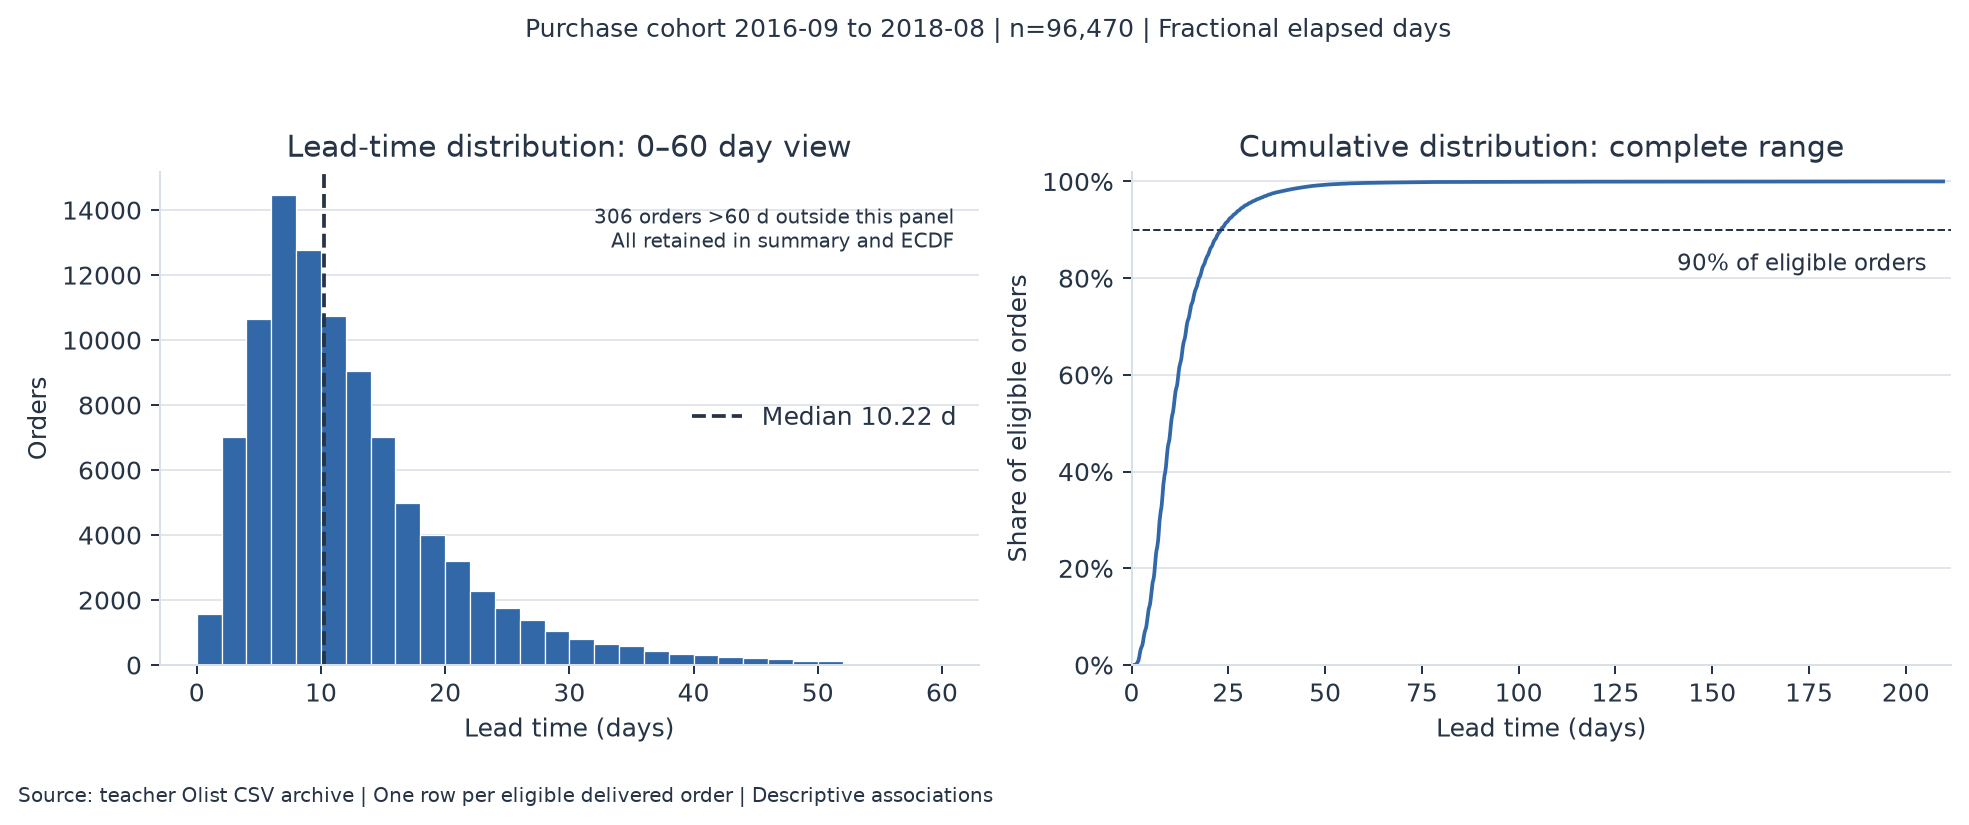

In [9]:
display(tables["sensitivity"])
print("Elapsed-day mean lost by flooring:", round(evidence["quality"]["flooring_mean_days_lost"], 4))
print("Orders >60 days (%):", round(evidence["quality"]["primary_over_60_days_pct"], 4))
figure_paths = make_figures(orders, tables, OUTPUT_DIR)
display(Image(filename=str(figure_paths[0])))

**Interpretation.** The mean exceeds the median and the upper percentiles extend well beyond the middle half of orders, indicating a right tail. Removing the 306 orders above 60 days reduces the mean from 12.56 to 12.32 days and the median from 10.22 to 10.20. These records are not automatically errors. The main summary retains them; the left histogram is a labelled display zoom. In Phase 2, compare robust error summaries and inspect large errors rather than hiding long deliveries.

### 7. Compare route groups

,route_group,n,median_days,mean_days,p90_days
0,All sellers same-state,34575,6.551,7.949,14.254
1,Any seller cross-state,61895,12.775,15.133,26.263


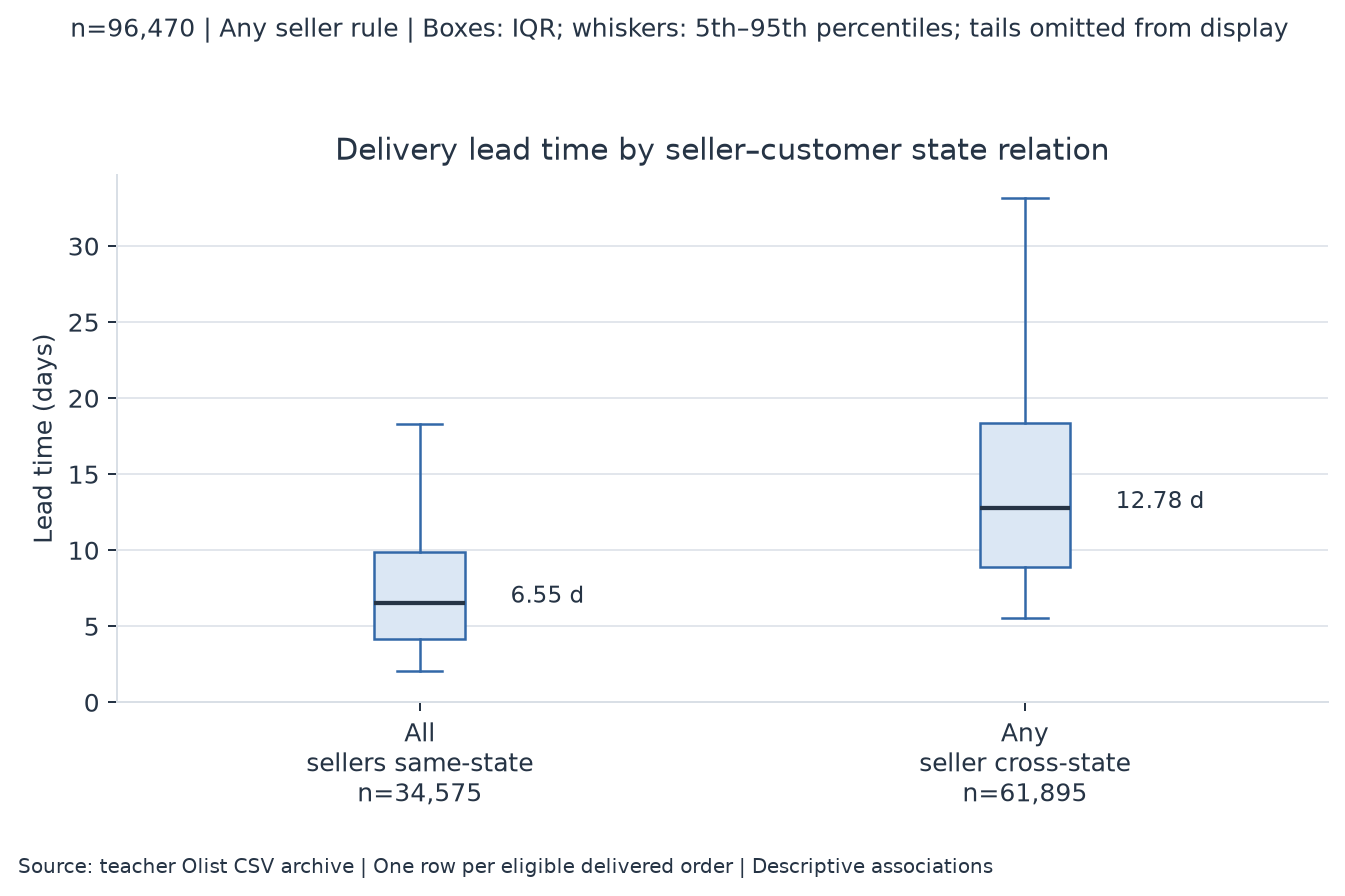

In [10]:
display(tables["route_summary"][["route_group", "n", "median_days", "mean_days", "p90_days"]])
display(Image(filename=str(figure_paths[1])))

**Interpretation.** The median is 6.55 days for same-state and 12.78 days for any-cross-state orders. The grouping uses all sellers, so 126 orders differ from a first-seller approximation. State relation is a coarse route proxy: differences can also reflect distance, service levels, sellers, products and purchase timing. This is not an estimated causal penalty for crossing a state boundary.

### 8. Compare purchase months

,purchase_month,n,median_days,p25_days,p75_days
3,2017-01,750,10.734,7.749,14.029
4,2017-02,1653,10.971,7.662,15.794
5,2017-03,2546,10.126,7.026,14.604
6,2017-04,2303,12.749,8.712,18.038
7,2017-05,3545,9.793,6.897,13.893
8,2017-06,3135,10.805,7.358,14.545
9,2017-07,3872,10.158,7.030,14.294
10,2017-08,4193,9.770,6.468,14.169
11,2017-09,4150,10.314,7.167,14.475
12,2017-10,4478,10.263,7.151,14.853


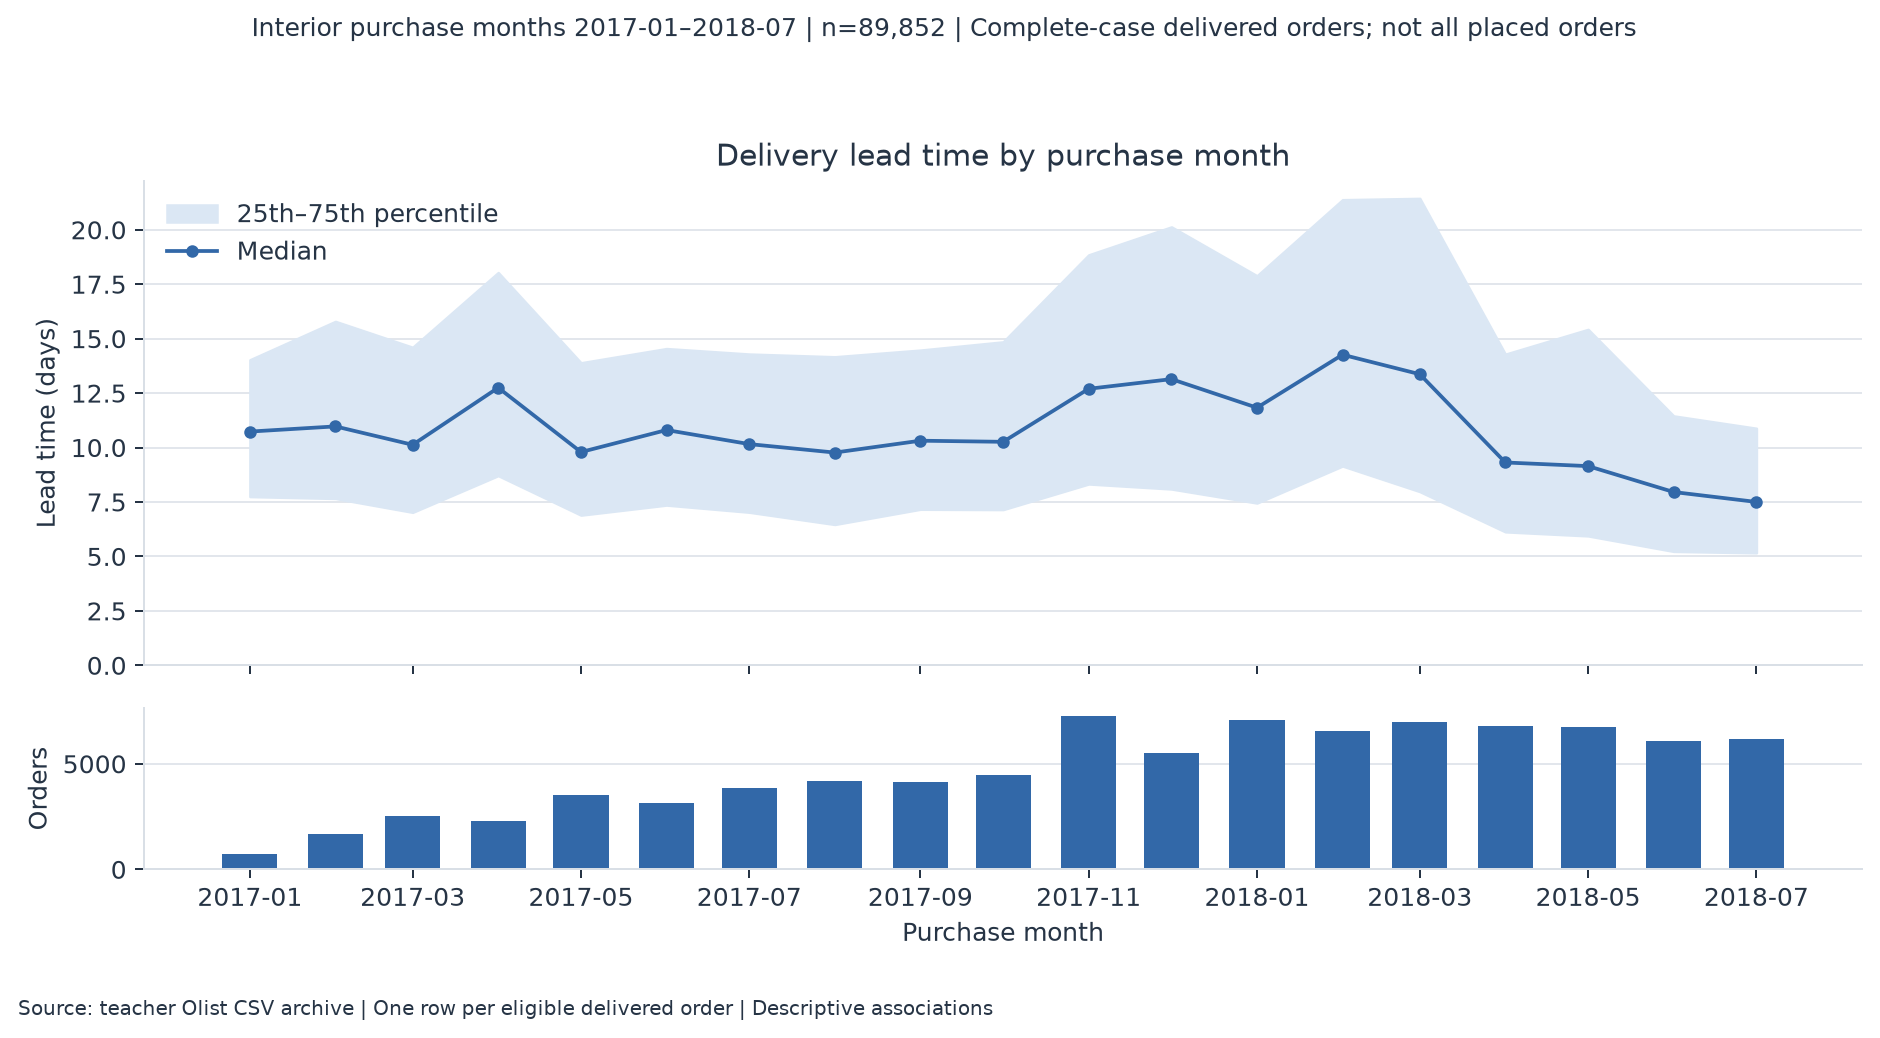

In [11]:
display(tables["monthly_summary"].query("in_plot_window")[["purchase_month", "n", "median_days", "p25_days", "p75_days"]])
display(Image(filename=str(figure_paths[2])))

**Interpretation.** Within the fixed interior window, the median is 14.26 days in February 2018 and 7.50 in July 2018. This supports inspecting purchase timing in later modelling, but does not explain the change or prove a repeatable seasonal effect. The graph excludes sparse 2016 purchase months and the final August 2018 edge; all months remain in the CSV and primary summary. Even interior months are conditional on observed completed deliveries, not a guarantee of full operational coverage.

### 9. Inspect numeric associations and freight groups

,feature,n,missing_orders,spearman_rho
0,total_freight,96470,0,0.382
1,total_price,96470,0,0.102
2,freight_ratio,96470,0,0.121
3,avg_product_weight_g,96448,22,0.094
4,item_count,96470,0,-0.025
5,seller_count,96470,0,-0.048


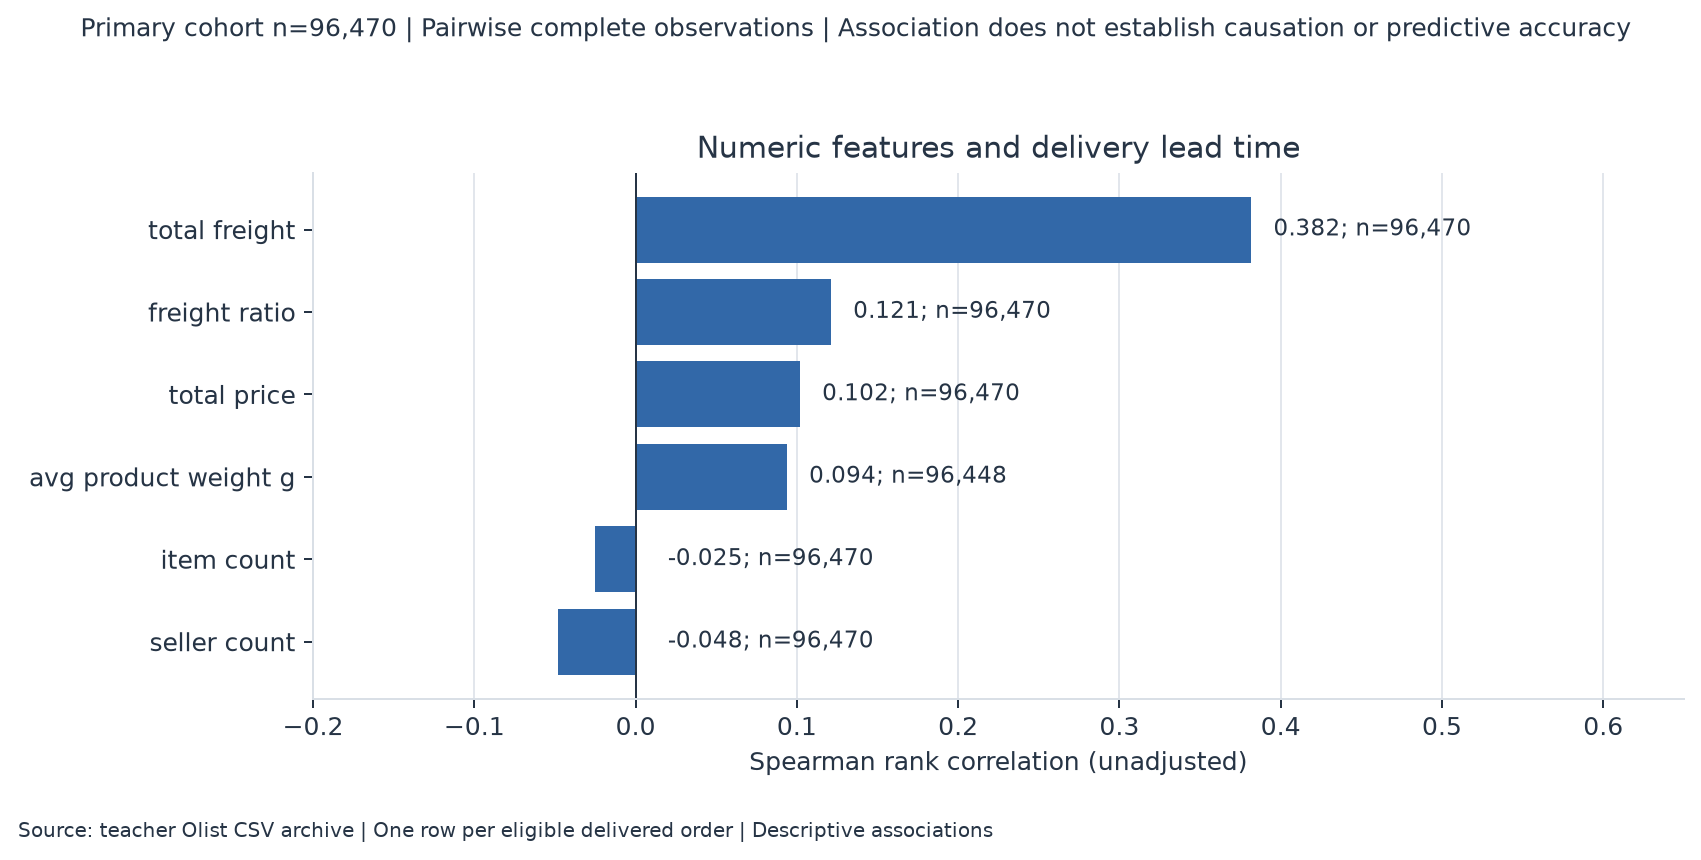

In [12]:
display(tables["numeric_associations"])
display(Image(filename=str(figure_paths[3])))

,freight_quintile,n,median_days,p25_days,p75_days
0,"(-0.001, 12.83]",19397,5.956,3.737,9.116
1,"(12.83, 15.64]",19192,9.763,6.839,14.154
2,"(15.64, 18.59]",19380,11.846,8.046,17.015
3,"(18.59, 27.38]",19225,11.910,8.029,17.716
4,"(27.38, 1794.96]",19276,13.084,8.757,19.322


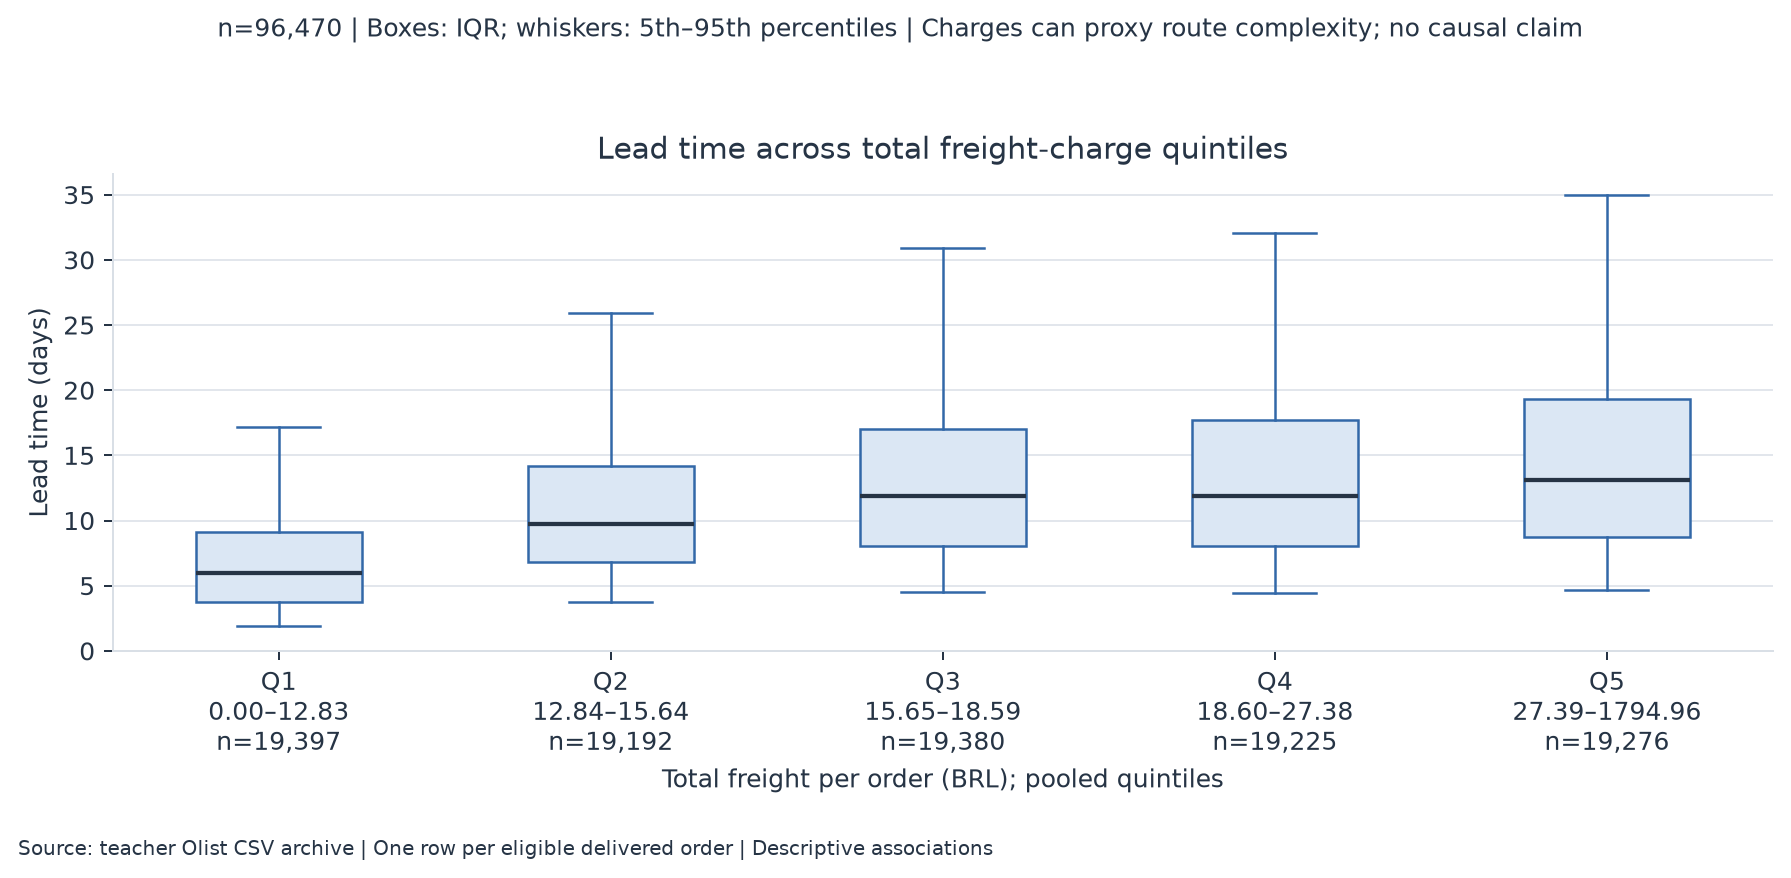

In [13]:
display(tables["freight_quintiles"][["freight_quintile", "n", "median_days", "p25_days", "p75_days"]])
display(Image(filename=str(figure_paths[4])))

### 10. Check whether a pooled relationship changes within route groups

This is a descriptive stratification check, not adjustment for every confounder. Pooled and within-group correlations do not measure the same population contrast.

In [14]:
display(tables["associations_within_route"])

,route_group,feature,n,spearman_rho
0,All sellers same-state,total_freight,34575,0.279
1,All sellers same-state,avg_product_weight_g,34570,0.154
2,All sellers same-state,total_price,34575,0.100
3,Any seller cross-state,total_freight,61895,0.121
4,Any seller cross-state,avg_product_weight_g,61878,0.061
5,Any seller cross-state,total_price,61895,0.036


**Interpretation.** Total freight has the largest absolute pooled rank correlation among the six numeric features examined (ρ≈0.382), but it falls to 0.279 within same-state and 0.121 within cross-state orders. This suggests that the pooled relationship partly reflects route composition; geography, seller mix and other factors may contribute. Price, freight ratio and average item weight show weaker marginal associations; item/seller counts show very weak negative associations. These are neither causal findings nor multivariable feature importance, and a weak marginal correlation does not rule out non-linear or interacting predictive value.

### 11. Inspect major states and product categories

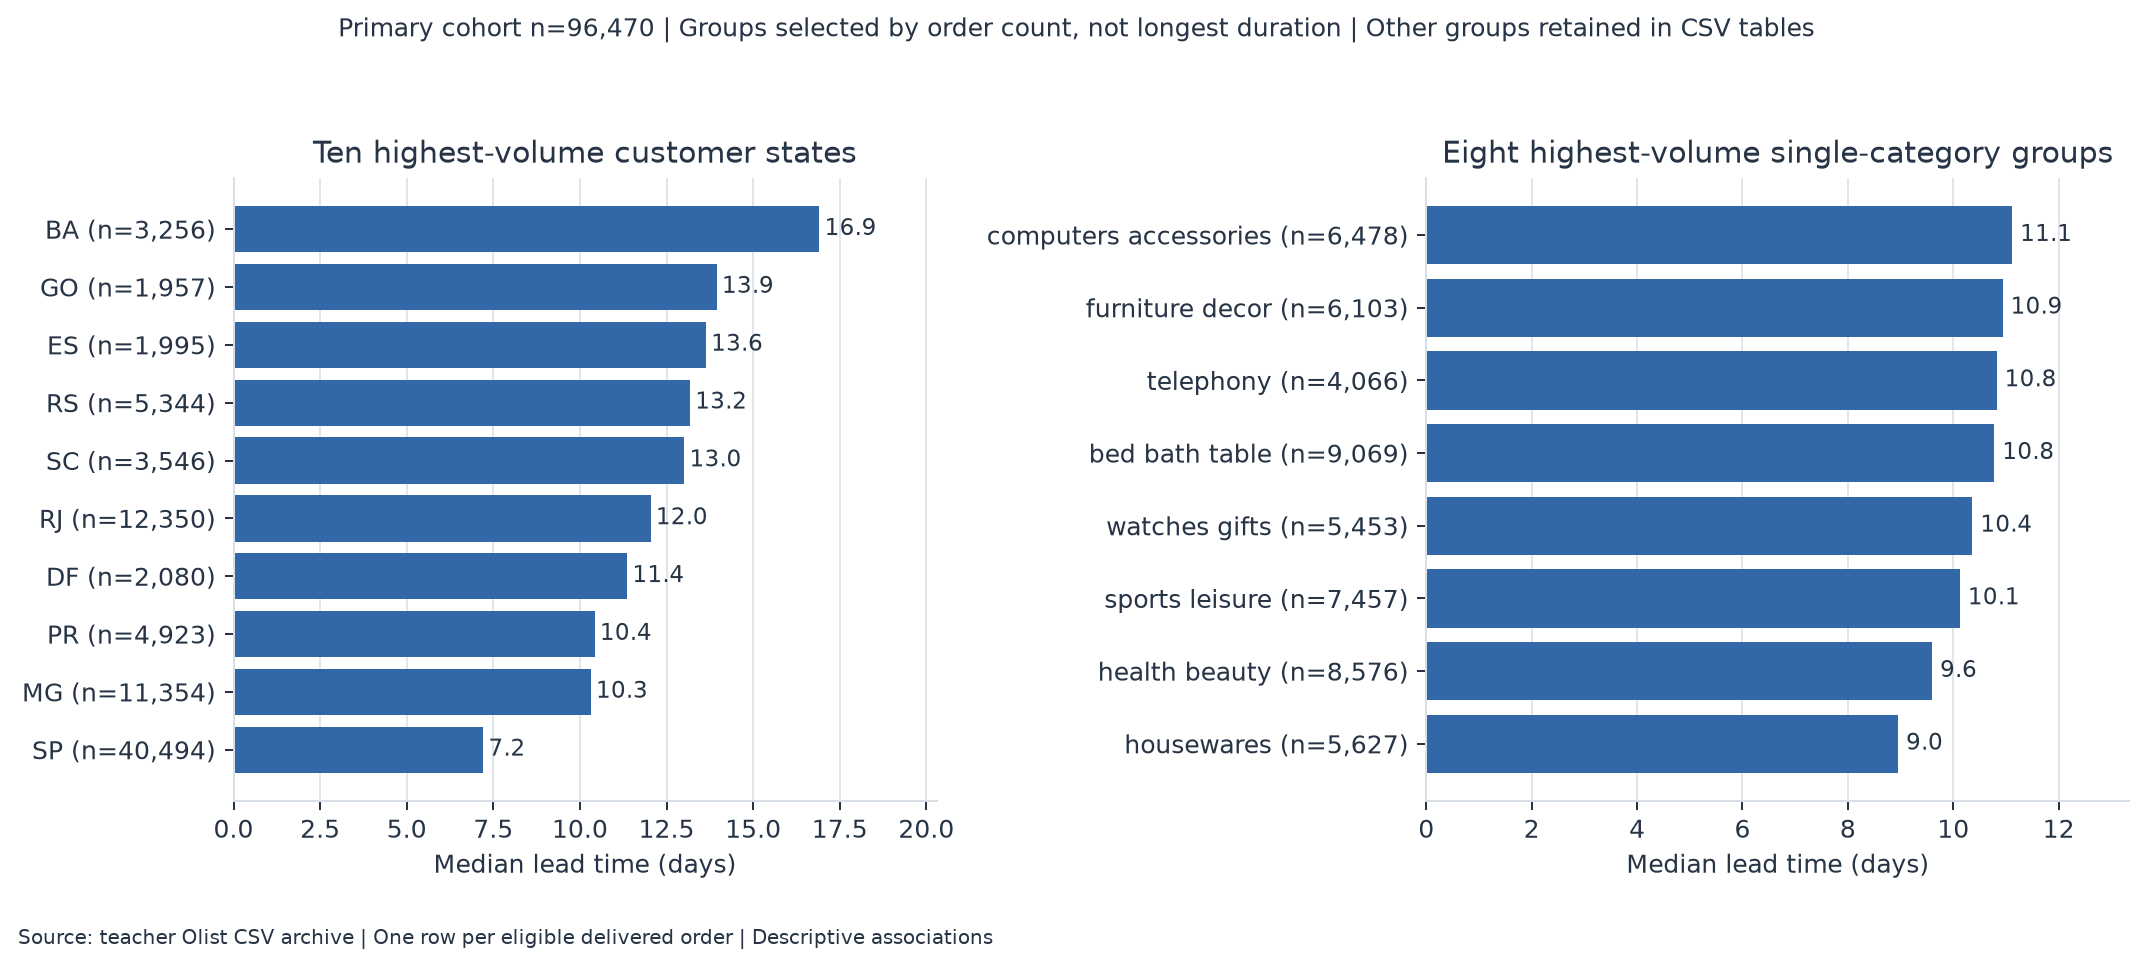

,category_group,n,median_days
9,bed_bath_table,9069,10.781
45,health_beauty,8576,9.600
69,sports_leisure,7457,10.127
17,computers_accessories,6478,11.119
41,furniture_decor,6103,10.937
51,housewares,5627,8.954
74,watches_gifts,5453,10.363
72,telephony,4066,10.825
7,auto,3773,9.747
73,toys,3752,9.436


In [15]:
display(Image(filename=str(figure_paths[5])))
display(tables["category_summary"].nlargest(10, "n")[["category_group", "n", "median_days"]])

**Interpretation.** High-volume states and product groups show differing typical delivery durations. The figure selects groups by volume first, rather than choosing those with the most extreme outcomes. It excludes mixed/incomplete categories only from the single-category panel; all orders remain in the primary analysis and complete tables. Category/state effects overlap with route and time patterns and should be evaluated jointly in Phase 2.

### 12. Verify grain and save reproducible evidence

#### Export function

Save reproducible results and source fingerprints to the configured output directory.

In [16]:
def write_outputs(frame, primary, provenance, summary, tables, zip_path=DEFAULT_ZIP, out=BASE):
    out = Path(out)
    for folder in ['tables','data','figures']: (out/folder).mkdir(exist_ok=True, parents=True)
    provenance.to_csv(out/'tables/source_inventory.csv', index=False)
    for name, table in tables.items(): table.to_csv(out/'tables'/f'{name}.csv', index=False)
    primary.drop(columns=['freight_quintile']).to_csv(out/'data/order_level_delivery.csv.gz', index=False, compression={'method':'gzip','mtime':0})
    excluded = frame.loc[~frame.is_primary, ['order_id','order_status','has_items','order_purchase_timestamp','order_delivered_customer_date','lead_time_days']].copy()
    excluded['exclusion_reason'] = np.select(
        [~excluded.has_items, excluded.order_status.ne('delivered'), excluded.lead_time_days.isna()],
        ['No item records', 'Status is not delivered', 'Missing purchase or delivery time'],
        default='Negative elapsed time')
    excluded.to_csv(out/'data/excluded_orders.csv', index=False)
    versions = {name: importlib.metadata.version(name) for name in ['pandas','numpy','scipy','matplotlib']}
    source = Path(zip_path)
    summary['provenance'] = {'archive_filename': source.name,
        'archive_sha256': hashlib.sha256(source.read_bytes()).hexdigest(),
        'project_reference_commit': '4c559b457839834aa1a4f459bbfdd1ee74dcd89c',
        'runtime_versions': versions, 'scope': 'M1 descriptive EDA only; no models fitted'}
    (out/'tables/evidence_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')

In [17]:
display(pd.DataFrame([evidence["grain_comparison"]]))
assert tables["route_summary"].n.sum() == len(orders)
assert tables["monthly_summary"].n.sum() == len(orders)
assert np.isclose(orders.lead_time_days.mean(), 12.558217098051976, atol=1e-10)
assert np.isclose(orders.lead_time_days.median(), 10.217476851851853, atol=1e-10)
write_outputs(all_orders, orders, source_inventory, evidence, tables, DATA_ZIP, OUTPUT_DIR)
print("Saved the derived data, summary tables and six figures.")

,correct_order_mean_days,item_weighted_mean_days,order_count,item_rows
0,12.558,12.472,96470,110189


Saved the derived data, summary tables and six figures.


## Takeaways

1. **Candidate problem:** predict purchase-to-delivery duration in days for comparable completed-delivery records, supporting fulfilment/customer-service planning. Later modelling must discuss how undelivered orders differ from this observed cohort.
2. **EDA evidence:** long-tailed duration, route differences, changes across purchase months, and a freight relationship that weakens within route groups. These motivate further investigation; they do not prove generalisation.
3. **Phase 2 preparation:** clarify prediction time; reserve an appropriate test period before further selection, check repeated customers, fit missing-value/encoding steps on training folds only, then compare the chosen families and sensible regression metrics such as MAE and RMSE. No family has been empirically selected here.
4. **Scope boundary:** this module supplies the project's descriptive delivery-duration analysis. The report draft summarises selected findings; predictive implementation and evaluation belong to Phase 2.
5. **Review status:** outputs were executed and key totals/route medians independently recomputed from the original archive. Cohort, join, denominator and summary checks are included in the executed cells; the source fingerprint and package versions are saved with the generated evidence.

### Sources, reuse and AI disclosure

- Teacher's `IT5006_Project-Data.zip` and `IT5006-Olist_Getting_Started.ipynb` supplied through Canvas; starter cells 20–21 and 30 provide joins, time and KPI examples.
- Project preparation reference: [late-delivery analysis](02_late_delivery_classification_eda.ipynb), cells 6–13; reference version `4c559b457839834aa1a4f459bbfdd1ee74dcd89c`. The archive fingerprint and preparation code are included for reproducibility; obtain the raw ZIP from the course materials.
- [Official IT5006 project briefing](https://prakashsukhwal.github.io/IT5006/IT5006_Project_Description_2026Aug_V2.html) supplies the M1/M2 scope.
- **AI disclosure draft:** Codex assisted with preparation of analysis code, plots and explanatory text. The numerical outputs were executed and independently checked. The material remains subject to review and revision before submission; this statement does not assert that human review has already occurred.

The source archive hash and package versions are saved in `delivery_lead_time_outputs/tables/evidence_summary.json` (or the configured output directory).